In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

군집화란 여러개의 데이터가 있을 때 비슷한 데이터끼리 묶어주는 것을 의미한다.  
비슷한 데이터끼리 묶어놓으면 관리하기 쉽다는 장점이 있다. 학원에서 초급반, 중급반, 고급반을 적절히 나눠 관리하면 편하다.  

머신러닝의 학습 방법 크게 지도 학습(supervised learning), 비지도 학습(unsupervised learning), 강화 학습(reinforcement learning)으로 나눌 수 있다.  
지도 학습이란 라벨링 된 데이터를 학습시키는 것을 의미하고, 비지도 학습 라벨링 되지 않는 데이터를 학습시키는 것을 의미하며, 강화 학습 행동(action)에 따른 보상(reward)으로 학습하는 것을 의미한다.  
라벨링이란 학습(트레이닝) 데이터에 정답(실제값, 관측값, 레이블, 클래스, 타겟)이 표시된 것을 의미한다. 데이터가 정답을 가지고 있으면 지도 학습, 정답을 가지고 있지 않으면 비지도 학습이라 한다.  

비지도 학습 알고리즘은 정답이 없으므로 정확한 방향성이 일치하지 않더라도 알아서 학습이 가능한 알고리즘으로 데이터를 군집화하는 알고리즘이 비지도 학습에 속한다.  
KMenas 알고리즘이 대표적인 비지도 학습 알고리즘이다.

머신러닝 알고리즘을 사용하기 위한 라이브러리를 설치하고 import 시킨다.

In [2]:
# !pip install scikit-learn
# 군집화(clustering)에 라이브러리를 import 시킨다.
from sklearn.cluster import KMeans

In [3]:
cluster_df = pd.read_csv('./data/cluster.csv')
cluster_df.head()

,x,y
0,2,3
1,2,11
2,2,18
3,4,5
4,4,7


In [4]:
# index 속성으로 데이터프레임의 행 인덱스를 얻어올 수 있다.
print(type(cluster_df.index))
print(cluster_df.index)
print(list(cluster_df.index))

<class 'pandas.RangeIndex'>
RangeIndex(start=0, stop=30, step=1)
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


In [5]:
# columns 속성으로 데이터프레임의 열 인덱스(열 이름)를 얻어올 수 있다.
print(type(cluster_df.columns))
print(cluster_df.columns)
print(list(cluster_df.columns))

<class 'pandas.Index'>
Index(['x', 'y'], dtype='str')
['x', 'y']


In [6]:
# values 속성으로 데이터프레임의 데이터를 numpy 배열 형태로 얻어올 수 있다.
print(type(cluster_df.values))
print(cluster_df.values)
point = cluster_df.values # 학습할 데이터

<class 'numpy.ndarray'>
[[ 2  3]
 [ 2 11]
 [ 2 18]
 [ 4  5]
 [ 4  7]
 [ 5  3]
 [ 5 15]
 [ 6  6]
 [ 6  8]
 [ 6  9]
 [ 7  2]
 [ 7  4]
 [ 7  5]
 [ 7 17]
 [ 7 18]
 [ 8  5]
 [ 8  4]
 [ 9 10]
 [ 9 11]
 [ 9 15]
 [ 9 19]
 [10  5]
 [10  8]
 [10 18]
 [12  6]
 [13  5]
 [14 11]
 [15  6]
 [15 18]
 [18 12]]


군집화 할 데이터 시각화

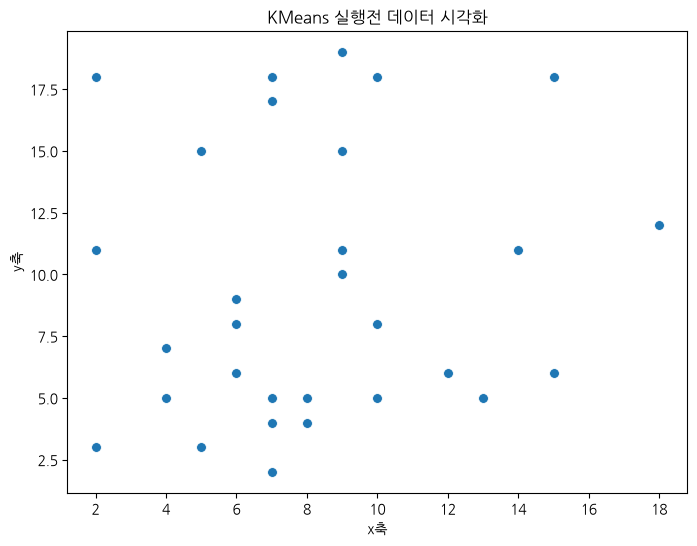

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=cluster_df, x='x', y='y', s=50)
plt.title('KMeans 실행전 데이터 시각화')
plt.xlabel('x축')
plt.ylabel('y축')
plt.show()

군집화를 실행하기 위해서 군집화를 실행할 데이터의 주제를 결정하고 얼마나 많은 cluster(군집)을 만들지 결정한다. 데이터가 정확할수록 유리하게 군집화를 할 수 있고 군집화를 실행하는 방법은 KMeans 등 다양한 방법이 있다.

KMeans 알고리즘 동작원리

무작위로 cluster의 중심을 선택하고 중심에 가까운 데이터를 cluster에 포함시키는 작업을 반복한 후 무작위로 선택된 cluster의 중심을 cluster에 포함된 데이터의 중앙으로 이동하는 과정을 반복 수행해서 더 이상 cluster의 중심 위치가 변하지 않을 때 까지 반복하는 것이 일반적인 방법이고 이러한 과정을 거치면 완벽하게 군집화된 cluster를 얻을 수 있다.

군집화를 위한 무작위로 cluster의 중심을 결정하는 방법은 먼저 임의의 데이터(노드)를 선택해서 cluster의 중심으로 설정(파랑색)한다.  
그 이후에는 무작위로 선택된 cluster의 중심에서 가장 거리가 먼 데이터(노랑색)를 선택해서 두 번째 cluster의 중심으로 설정한다.  
다음 부터는 이미 선택된 cluster(파랑색, 노랑색)의 중심들로부터 가장 멀리 떨어져있는 데이터(녹색)을 선택해서 cluster의 중심으로 선택하는 작업을 반복한다.

<img src="Clustering1.png" width="1200" align="left" />

위와 같이 cluster의 중심을 선택하는 작업을 했더니 1, 2, 3 세 개의 cluster가 존재한다고 가정하고 각각의 데이터를 선택해서 세 개의 cluster 중심에서 가장 가까운 cluster에 속하도록 만드는 작업을 반복해서 실행한다.

<img src="Clustering2.png" width="1200" align="left" />

이러한 과정을 반복해 실행하면 아래 왼쪽의 그림과 같을 것이다.

<img src="Clustering3.png" width="1200" align="left" />

위 왼쪽 그림과 같이 대략적로 군집화가 완료되면 완벽한 군집화를 위해 cluster 중심 위치를 위의 오른쪽 그림과 같이 군집화된 데이터들의 중심으로 이동시킨다.  
cluster의 중심을 이동시키고 다시 모든 데이터에 대해서 어떤 cluster의 중심에 가까운지를 하나씩 체크해서 만약 특정 데이터가 다른 cluster의 중심에 더 가깝다면 그 cluster에 속하도록 설정하는 작업을 반복한다.

cluster의 중심 위치가 더 이상 바뀌지 않으면 군집화가 끝난것이다.

KMeans 알고리즘을 이용해서 cluster 4개를 생성한다.

In [8]:
# sklearn 라이브러리가 제공하는 KMeans 알고리즘을 이용해서 모델을 만들고 데이터를 넣어서 학습시킨다.
# n_clusters는 군집화할 cluster의 개수를 지정하는 하이퍼파라미터이다.
kmeans = KMeans(n_clusters=4).fit(point)
print(kmeans)

KMeans(n_clusters=4)


In [9]:
# cluster_centers_ 속성으로 군집화된 cluster의 중심 위치를 얻어올 수 있다.
print(kmeans.cluster_centers_)
# labels_ 속성으로 각각의 데이터가 군집화된 cluster를 얻어온다.
print(kmeans.labels_)

[[ 5.53846154  5.53846154]
 [ 7.         17.14285714]
 [11.14285714  7.28571429]
 [15.66666667 13.66666667]]
[0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 0 0 2 2 1 1 2 2 1 2 2 3 2 3 3]


데이터프레임에 cluster라는 파생 변수를 추가하고 군집화된 결과(labels_)를 넣어준다.

In [10]:
cluster_df['cluster'] = kmeans.labels_
cluster_df.to_csv('./data/save.csv', index=False)
cluster_df

,x,y,cluster
0,2,3,0
1,2,11,0
2,2,18,1
3,4,5,0
4,4,7,0
5,5,3,0
6,5,15,1
7,6,6,0
8,6,8,0
9,6,9,0


군집화 된 데이터 시각화

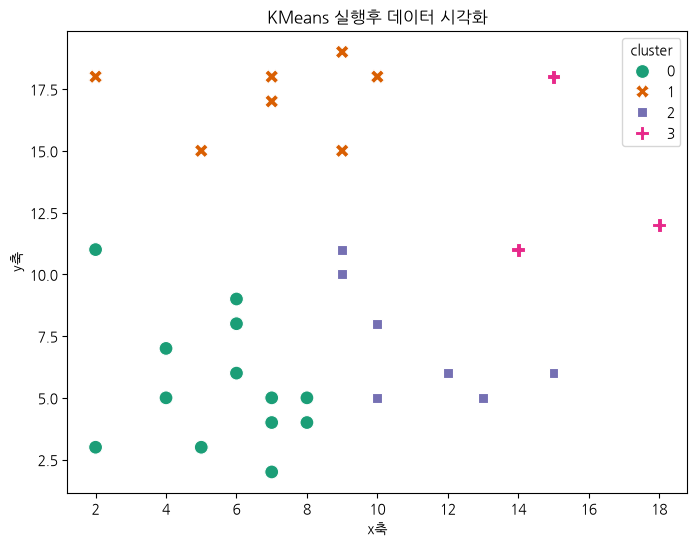

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=cluster_df, x='x', y='y', s=100, hue='cluster', palette='Dark2', style='cluster')
plt.title('KMeans 실행후 데이터 시각화')
plt.xlabel('x축')
plt.ylabel('y축')
plt.show()

<img src="palette.png" width="1200" align="left" />